In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from itertools import combinations
import utils

In [2]:
def plot_admg(G,B):
    options = {
    "font_size": 10,
    "node_size": 300,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
    }
    G_B = nx.Graph()
    G_B.add_nodes_from(G.nodes)
    G_B.add_edges_from(B)
    jitter_strength = 0.1
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes:
            G.nodes[node]["layer"] = layer
    pos = nx.multipartite_layout(G, subset_key="layer")
    pos = {
    node: (x + random.uniform(-jitter_strength, jitter_strength),
        y + random.uniform(-jitter_strength, jitter_strength))
    for node, (x, y) in pos.items()
    }
    nx.draw_networkx(G, pos=pos, **options)
    nx.draw_networkx_edges(G_B, pos, edge_color="red", arrows=True, arrowstyle="<->", connectionstyle="arc3, rad=0.5", style="dashed")
    ax = plt.gca()
    ax.margins(0.20)
    plt.show()

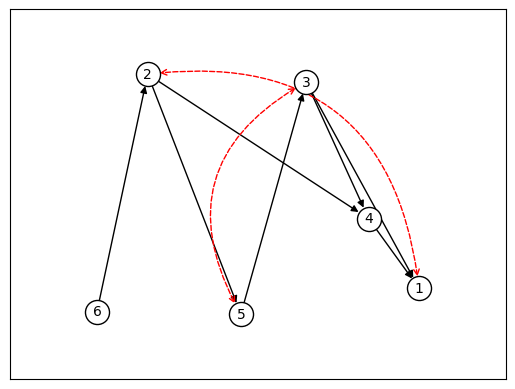

In [3]:
G = nx.DiGraph()
n = 6
V = range(1,n+1)
E = [(2,4),(2,5),(3,4),(3,1),(4,1),(5,3),(6,2)]
B = [(5,3),(1,2)]
G.add_nodes_from(V)
G.add_edges_from(E)
plot_admg(G,B)

In [4]:
def path_rank(G, X, Y):
    if not X or not Y:
        return 0
    H = nx.DiGraph()
    for v in G.nodes():
        H.add_edge((v, 'in'), (v, 'out'), capacity=1)
    for u, v in G.edges():
        H.add_edge((u, 'out'), (v, 'in'), capacity=len(G))
    S = 'S'
    T = 'T'
    for x in X:
        H.add_edge(S, (x, 'in'), capacity=len(G))
    for y in Y:
        H.add_edge((y, 'out'), T, capacity=len(G))
    flow_value, _ = nx.maximum_flow(H, S, T)
    return flow_value

In [5]:
X = [6,2]
Y = [6,4,1]
print(path_rank(G,X,Y))

2


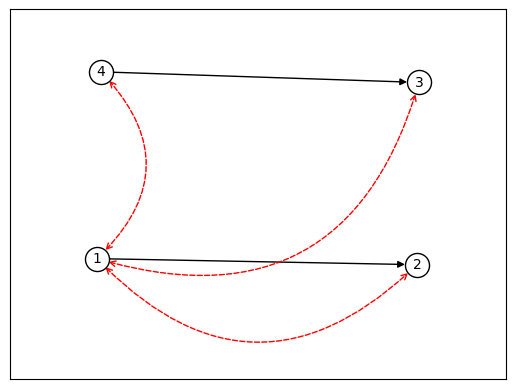

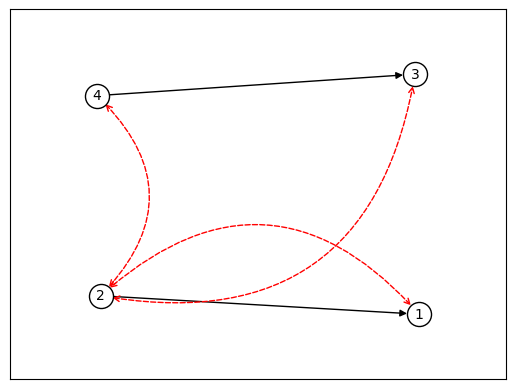

In [6]:
n = 4
V = range(1,n+1)

G1 = nx.DiGraph()
E1 = [(1,2),(4,3)]
B1 = [(1,2),(1,3),(1,4)]
G1.add_nodes_from(V)
G1.add_edges_from(E1)

G2 = nx.DiGraph()
E2 = [(2,1),(4,3)]
B2 = [(1,2),(2,3),(2,4)]
G2.add_nodes_from(V)
G2.add_edges_from(E2)

plot_admg(G1,B1)
plot_admg(G2,B2)

In [7]:
def non_connected_pairs(vertices, edgelist):
    edge_set = {tuple(sorted((u, v))) for u, v in edgelist}
    return [
        (u, v)
        for u, v in combinations(vertices, 2)
        if (u, v) not in edge_set
    ]

In [8]:
def extended_pairs(vertices, edgelist):
    self_pairs = [(i, i) for i in vertices]
    symB1 = [(j, i) for i, j in edgelist]
    return edgelist + symB1 + self_pairs

In [9]:
B1,B2

([(1, 2), (1, 3), (1, 4)], [(1, 2), (2, 3), (2, 4)])

In [10]:
non_connected_pairs(V, B2), extended_pairs(V, B1)

([(1, 3), (1, 4), (3, 4)],
 [(1, 2),
  (1, 3),
  (1, 4),
  (2, 1),
  (3, 1),
  (4, 1),
  (1, 1),
  (2, 2),
  (3, 3),
  (4, 4)])

In [11]:
def induced_graph(V,B1,B2):
    IG = nx.Graph()
    for i in V:
        for j in V:
            IG.add_node((i, j))
    for u, v in non_connected_pairs(V, B2):
        for i,j in extended_pairs(V, B1):
            IG.add_edge((u,i),(v,j))
    return IG


In [12]:
def plot_induced(IG):
    options = {
    "font_size": 6,
    "node_size": 500,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
    }
    pos = {(i, j): (j, i) for i, j in IG.nodes()}
    nx.draw_networkx(IG,pos, arrows=True, **options, connectionstyle="arc3,rad=0.2")
    plt.gca().invert_yaxis()
    ax = plt.gca()
    ax.margins(0.20)
    plt.show()


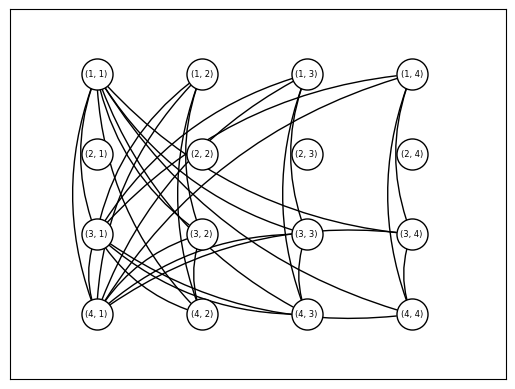

In [13]:
IG = induced_graph(V,B1,B2)
plot_induced(IG)

In [14]:
def trivial_row(V, edges):
    vertices = set(V)
    endpoints = set()
    for u, v in non_connected_pairs(V, edges):
        endpoints.add(u)
        endpoints.add(v)
    return list(vertices - endpoints)

In [15]:
def get_removable(V, G1, G2, B2):
    removable = []
    unremovable = []
    for i in V:
        if i not in trivial_row(V, B2):
            for j in V:
                if path_rank(G1, [j], list(G2.predecessors(i)) + [i]) == 0:
                    removable.append((i,j))
                else:
                    if path_rank(G1, [j], list(G2.predecessors(i))) == 0:
                        unremovable.append((i,j))
        else:
            for j in V:
                removable.append((i,j))

    return removable, unremovable

In [16]:
get_removable(V, G1, G2, B2)[0], get_removable(V, G1, G2, B2)[1]

([(1, 3),
  (1, 4),
  (2, 1),
  (2, 2),
  (2, 3),
  (2, 4),
  (3, 1),
  (3, 2),
  (4, 1),
  (4, 2),
  (4, 3)],
 [(3, 3), (4, 4)])

In [17]:
def IG_clean_up(IG, G1, G2, B2):
    V = list(G1.nodes())
    remain = set(IG.nodes)-set(get_removable(V, G1, G2, B2)[0])
    IG_re = IG.subgraph(remain).copy()
    IG_re.remove_nodes_from(list(nx.isolates(IG_re)))
    return IG_re

In [18]:
def neighbors_of_set(G, S):
    result = set()
    for u in S:
        result.update(G.neighbors(u))
    return result - set(S)  # remove the original nodes if desired

In [19]:
def is_vertex_cover(E, S):
    S = set(S)
    for u, v in E:
        if u not in S and v not in S:
            return False
    return True

In [20]:
def plot_auxiliary(G1, G2, B1, B2):
    V = list(G1.nodes())
    IG = induced_graph(V, B1, B2)
    IG_cleaned = IG_clean_up(IG, G1, G2, B2)
    unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
    unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)
    node_colors = [
    "#d62728" if node in unremovable else
    "#1f77b4" if node in unremovable_neighbors else
    "white"
    for node in IG_cleaned.nodes()
    ]
    options = {
    "font_size": 6,
    "node_size": 500,
    "node_color": node_colors,
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
    }
    pos = {(i, j): (j, i) for i, j in IG_cleaned.nodes()}
    nx.draw_networkx(IG_cleaned, pos, arrows=True, **options, connectionstyle="arc3,rad=0.2")
    plt.gca().invert_yaxis()
    ax = plt.gca()
    ax.margins(0.20)
    plt.show()
    return(is_vertex_cover(IG_cleaned.edges, unremovable_neighbors | unremovable))

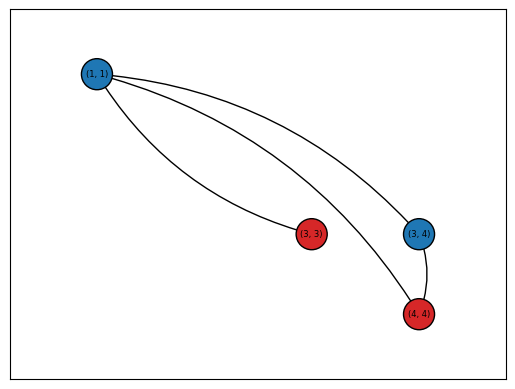

True

In [21]:
plot_auxiliary(G1, G2, B1, B2)

In [25]:
utils.is_good(G1,G2,B1,B2)

True

In [26]:
list(G1.nodes())
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)
unremovable, unremovable_neighbors

({(3, 3), (4, 4)}, {(1, 1), (3, 4)})

In [35]:
type(unremovable_neighbors)

set

In [36]:
def get_j(S, i):
    return {j for x, j in S if x == i}

In [38]:
get_j(unremovable_neighbors,1)

{1}

In [32]:
IG_cleaned.subgraph(unremovable).number_of_edges() > 0

False

In [43]:
G2.ancestors

AttributeError: 'DiGraph' object has no attribute 'ancestors'

In [46]:
i = 2
X = get_j(unremovable_neighbors,i)
Y = list(G2.predecessors(i))
path_rank(G1, X, Y + [i]) == path_rank(G1, X, Y)

True

range(1, 5)

In [57]:
for i in V:
    X = get_j(unremovable_neighbors,i)
    Y = list(G2.predecessors(i))
    if not path_rank(G1, X, Y + [i]) == path_rank(G1, X, Y):
        print("false")
print("true")

true


In [ ]:
utils.path_rank(G1,)